In [97]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Ecommerce_dataset.csv")

In [101]:
df.shape

(10200, 13)

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        10200 non-null  object 
 1   Order_Date      10200 non-null  object 
 2   Customer_ID     10200 non-null  object 
 3   Customer_Name   9999 non-null   object 
 4   Category        10200 non-null  object 
 5   Sub_Category    10200 non-null  object 
 6   Quantity        10200 non-null  object 
 7   Unit_Price      10200 non-null  object 
 8   Discount        10200 non-null  float64
 9   Sales           10200 non-null  float64
 10  Profit          10200 non-null  float64
 11  Region          9998 non-null   object 
 12  Payment_Method  9995 non-null   object 
dtypes: float64(3), object(10)
memory usage: 1.0+ MB


In [103]:
df.isnull().sum()

Order_ID            0
Order_Date          0
Customer_ID         0
Customer_Name     201
Category            0
Sub_Category        0
Quantity            0
Unit_Price          0
Discount            0
Sales               0
Profit              0
Region            202
Payment_Method    205
dtype: int64

In [104]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Category,Sub_Category,Quantity,Unit_Price,Discount,Sales,Profit,Region,Payment_Method
0,ORD100000,2023-09-26 00:00:00,CUST1654,Karan Iyer,Office Supplies,Binders,2,880.21,0.24,1337.92,329.74,South,UPI
1,ORD100001,2025-05-01 00:00:00,CUST1114,Sneha Gupta,Technology,Copiers,2,592.03,0.26,876.20,49.94,South,Credit Card
2,ORD100002,2025-04-01 00:00:00,CUST1025,Arjun Patel,Office Supplies,Paper,4,884.42,0.08,3254.67,215.98,East,NaN
3,ORD100003,2023-01-03 00:00:00,CUST1759,Rohit Verma,Office Supplies,Storage,9,236.08,0.13,1848.51,335.39,West,Net Banking
4,ORD100004,2023-07-25 00:00:00,CUST1281,Amit Das,Technology,Accessories,8,208.63,0.01,1652.35,136.16,north,Debit Card


In [ ]:
## Initial Data Observations

# Dataset contains 10,200 rows and 13 columns.
# 3 numerical columns: Discount, Sales, Profit.
# 10 object columns.
# Quantity and Unit_Price are incorrectly stored as objects.
# Order_Date is stored as an object (should be a datetime).
# Missing values present in:
  # Customer_Name (201)
  # Region (202)
  # Payment_Method (205)
# Duplicate rows likely exist (dataset was intentionally created with duplicates).

In [105]:
# Fixing Qunatity & Unit_price

df['Quantity'] = pd.to_numeric(df['Quantity'], errors="coerce")
df['Unit_Price'] = pd.to_numeric(df['Unit_Price'], errors="coerce")

In [106]:
# Checking for null values

df[['Quantity','Unit_Price']].isnull().sum()

Quantity      104
Unit_Price    100
dtype: int64

In [107]:
# Removing the rows with null values

df = df.dropna(subset=['Quantity','Unit_Price'])

In [109]:
# Fixing the datatype of Order_date

df.loc[:, 'Order_Date'] = pd.to_datetime(df['Order_Date'], errors="coerce")

In [110]:
df['Order_Date'].isnull().sum()

np.int64(101)

In [111]:
# Removing the rows with null values

df = df.dropna(subset=['Order_Date'])

In [112]:
# Handling Missing Categorical Values

df.loc[:, 'Customer_Name'] = df['Customer_Name'].fillna("Unknown")

In [113]:
# Filling the missing values with the most frequent Value(mode)

df.loc[:,'Region'] = df['Region'].fillna(df['Region'].mode()[0])

In [114]:
# Filling the missing values with the most frequent Value(mode)

df.loc[:, 'Payment_Method'] = df['Payment_Method'].fillna(df['Payment_Method'].mode()[0])

In [115]:
# Fixing Text Inconsistencies

df['Region'].unique()

array(['South', 'East', 'West', 'north', 'Central'], dtype=object)

In [116]:
df.loc[:,'Region'] = df['Region'].replace('north','North')

In [117]:
# Removing Duplicate Rows

df.duplicated().sum()

np.int64(179)

In [118]:
df = df.drop_duplicates()

In [119]:
# Creating a Revenue Column

df['Revenue'] = df['Quantity'] * df['Unit_Price']

In [120]:
df[['Quantity','Unit_Price','Revenue']].head()

,Quantity,Unit_Price,Revenue
0,2.0,880.21,1760.42
1,2.0,592.03,1184.06
2,4.0,884.42,3537.68
3,9.0,236.08,2124.72
4,8.0,208.63,1669.04


In [121]:
# Extracting Year & Month

df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month

In [122]:
df['Month_Name'] = df['Order_Date'].dt.month_name()

In [123]:
# Business Metrics

# Total Revenue

df['Revenue'].sum()

np.float64(25857601.65)

In [127]:
# Total Order

df['Order_ID'].nunique()

9709

In [128]:
# Total Customers

df['Customer_ID'].nunique()

1000

In [130]:
# Average Order value (AOV)

df.groupby('Order_ID')['Revenue'].sum().mean().round(2)

np.float64(2663.26)

In [131]:
# Revenue By Region

df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)

Region
West       6912772.98
East       6280624.22
Central    6207673.04
South      6197218.99
North       259312.42
Name: Revenue, dtype: float64

In [132]:
df.groupby('Month_Name')['Revenue'].sum()

Month_Name
April        2125393.92
August       2304187.15
December     2040720.84
February     1854170.58
January      2302291.70
July         2151529.83
June         2267038.93
March        2167772.51
May          2235636.04
November     2047645.11
October      2334346.86
September    2026868.18
Name: Revenue, dtype: float64

In [134]:
# Top 5 Customer

top_customers = (df.groupby('Customer_ID')['Revenue'].sum().sort_values(ascending=False).head(5))
top_customers

Customer_ID
CUST1970    64903.13
CUST1710    61255.04
CUST1339    59969.81
CUST1140    58591.41
CUST1794    58179.91
Name: Revenue, dtype: float64

In [135]:
# Monthly Revenue Trend

monthly_revenue = (df.groupby(['Year','Month_Name'])['Revenue'].sum().reset_index())
monthly_revenue

,Year,Month_Name,Revenue
0,2023,April,697981.51
1,2023,August,831121.91
2,2023,December,662347.65
3,2023,February,586933.43
4,2023,January,765259.37
5,2023,July,629962.31
6,2023,June,714559.95
7,2023,March,703825.66
8,2023,May,686206.94
9,2023,November,662863.43


In [136]:
# Top Category by Revenue

top_products = (df.groupby('Category')['Revenue'].sum().sort_values(ascending=False).head(10))
top_products

Category
Technology         8694647.84
Office Supplies    8620443.12
Furniture          8542510.69
Name: Revenue, dtype: float64

In [138]:
# Customer Order Frequency

customer_orders = (df.groupby('Customer_ID')['Order_ID'].nunique().sort_values(ascending=False))

customer_orders.head()

Customer_ID
CUST1339    21
CUST1794    20
CUST1563    19
CUST1095    19
CUST1738    19
Name: Order_ID, dtype: int64

In [139]:
monthly_revenue["Growth_%"] = monthly_revenue['Revenue'].pct_change() * 100

monthly_revenue

,Year,Month_Name,Revenue,Growth_%
0,2023,April,697981.51,NaN
1,2023,August,831121.91,19.075061
2,2023,December,662347.65,-20.306800
3,2023,February,586933.43,-11.385897
4,2023,January,765259.37,30.382652
5,2023,July,629962.31,-17.679896
6,2023,June,714559.95,13.429000
7,2023,March,703825.66,-1.502224
8,2023,May,686206.94,-2.503279
9,2023,November,662863.43,-3.401818


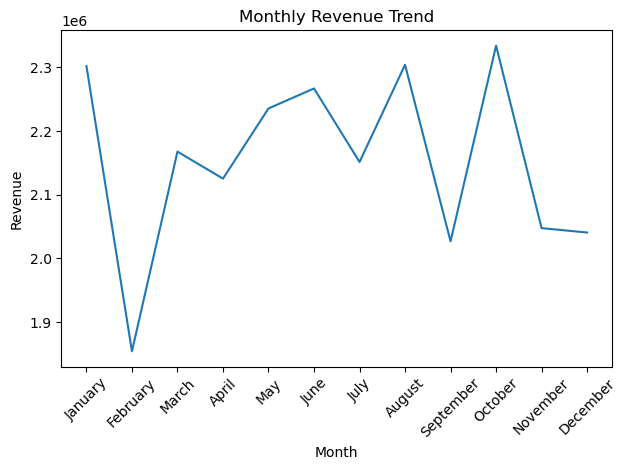

In [152]:
# Monthly Revenue Trend Chart

monthly_revenue = (
    df.groupby(['Month', 'Month_Name'])['Revenue']
      .sum()
      .reset_index()
      .sort_values('Month')   # Ensures Jan → Dec order
)

plt.figure()
plt.plot(monthly_revenue['Month_Name'], monthly_revenue['Revenue'])

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Business Insights

# Revenue demonstrates an overall upward trend during March, May, June, August, and October, 
# indicating periods of strong customer demand and positive market performance.

# However, revenue declines are observed in February, April, July, September, and November, 
# suggesting potential seasonal slowdowns or operational inefficiencies. Further investigation 
# into marketing campaigns, pricing strategies, or external factors during these months is recommended.

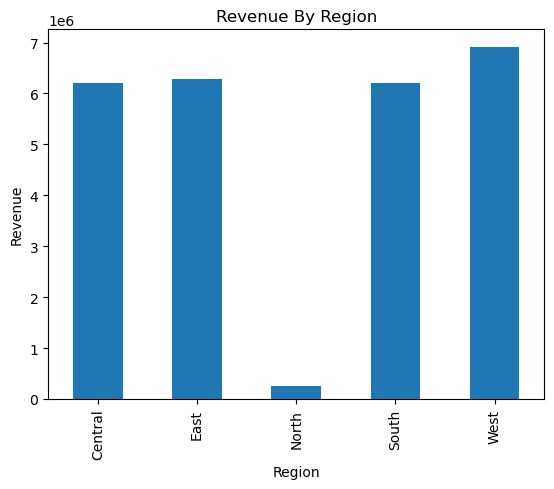

In [145]:
# Revenue By Region Chart

region_revenue = df.groupby('Region')['Revenue'].sum()

plt.figure()
region_revenue.plot(kind='bar')
plt.title("Revenue By Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()

In [ ]:
# Business Insights

# The West Region contributes the highest share of total revenue, 
# indicating strong market penetration and brand presence in this area.

# Expanding targeted marketing and promotional strategies in the North Region 
# could help diversify revenue streams and reduce regional dependency risk.

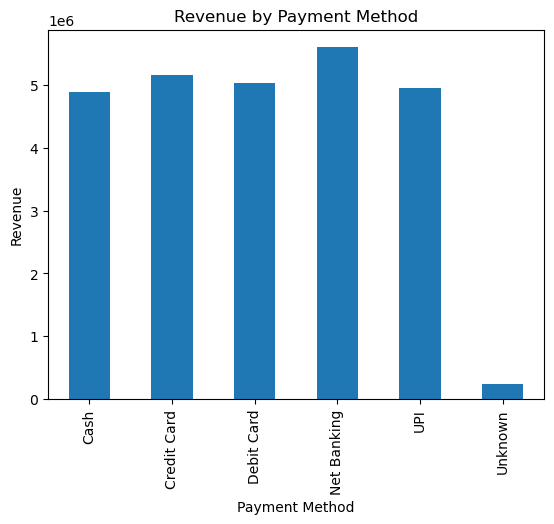

In [146]:
# Revenue by Payment Method chart

payment_revenue = df.groupby('Payment_Method')['Revenue'].sum()

plt.figure()
payment_revenue.plot(kind='bar')
plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.show()

In [ ]:
# Business Insights

# The dominance of digital payment methods highlights a strong customer preference for convenience and cashless transactions. 
# Maintaining a secure, seamless, and optimized digital payment infrastructure is essential to sustain customer satisfaction.

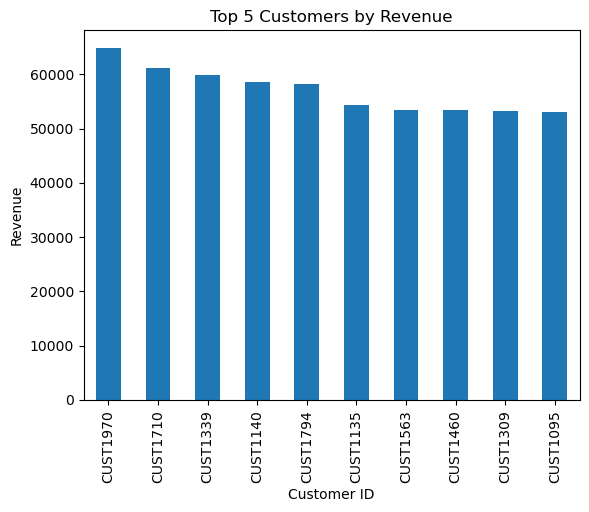

In [153]:
# Top 10 Customers by Revenue Chart

top_customers = (df.groupby('Customer_ID')['Revenue'].sum().sort_values(ascending=False).head(10))

plt.figure()
top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

In [ ]:
# Business Insights 

# Revenue is not overly concentrated among a small group of customers, indicating a healthy and diversified customer base. 
# This reduces revenue risk associated with customer dependency

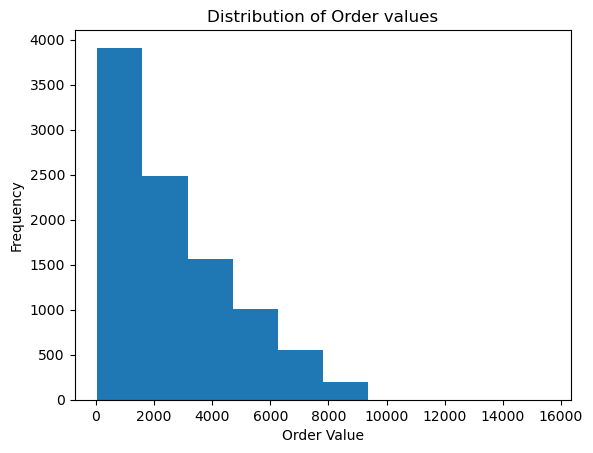

In [151]:
# Order Value Distribution Chart

order_value = df.groupby('Order_ID')['Revenue'].sum()

plt.figure()
plt.hist(order_value)
plt.title('Distribution of Order values')
plt.xlabel('Order Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Business Insights

# The majority of orders fall within the lower-value range, presenting opportunities for upselling, bundling, 
# and cross-selling strategies to increase Average Order Value (AOV) and overall profitability.